In [1]:
import pandas as pd
import numpy as np

In [2]:
#Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

In [3]:
#Algorithms
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor


In [4]:
#Tuning
from sklearn.model_selection import RandomizedSearchCV

In [5]:
#Metrics
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

In [6]:
df = pd.read_csv('House_Price_Egypt.csv')
unnamed_cols = [c for c in df.columns if c.startswith('Unnamed')]
df.drop(columns=unnamed_cols, inplace=True)


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20465 entries, 0 to 20464
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Type            20465 non-null  object
 1   Price           20465 non-null  int64 
 2   Bedrooms        20465 non-null  int64 
 3   Bathrooms       20465 non-null  int64 
 4   Area            20465 non-null  int64 
 5   Furnished       20465 non-null  object
 6   Level           20465 non-null  int64 
 7   Payment_Option  20465 non-null  object
 8   Delivery_Term   20465 non-null  object
 9   City            20465 non-null  object
dtypes: int64(5), object(5)
memory usage: 1.6+ MB


In [8]:
df['Area']     = df['Area'].replace('Unknown', np.nan)
df['Bedrooms'] = df['Bedrooms'].replace('Unknown', np.nan)
df['Bathrooms'] = df['Bathrooms'].replace('Unknown', np.nan)
df['Price']    = df['Price'].replace('Unknown', np.nan)
# Only drop rows where essential numeric columns are missing
df.dropna(subset=['Area', 'Bedrooms', 'Bathrooms', 'Price'], inplace=True)


In [9]:
df['Bedrooms']      = df['Bedrooms'].replace('10+', 11)
df['Bathrooms']     = df['Bathrooms'].replace('10+', 11)
df['Furnished']     = df['Furnished'].replace('Unknown', 'No')
df['Payment_Option']= df['Payment_Option'].replace('Unknown', 'Cash')
df['Delivery_Term'] = df['Delivery_Term'].replace('Unknown ', 'Not Finished')
# Compound — capital C, fill any Unknown/NaN before encoding
if 'Compound' in df.columns:
    df['Compound'] = df['Compound'].replace('Unknown', 'No').fillna('No')


In [10]:
df['Bedrooms'] = df['Bedrooms'].astype(int)
df['Bathrooms'] = df['Bathrooms'].astype(int)
df['Area'] = df['Area'].astype(float).astype(int)
df['Price'] = df['Price'].astype(int)

In [11]:
print(df['Level'].unique())
print(df['Type'].unique())
print(df['Payment_Option'].unique())

[12  2  4  0  1  3  9  7  5  6 10 11  8]
['Penthouse' 'Apartment' 'Duplex' 'Studio']
['Cash' 'Installment' 'Cash or Installment']


In [12]:
df = df.drop(df[(df['Level'] == 'Unknown') & (df['Type'] == 'Duplex')].index)
df = df.drop(df[(df['Level'] == 'Unknown') & (df['Type'] == 'Apartment')].index)
df = df.drop(df[(df['Level'] == 'Unknown') & (df['Type'] == 'Studio')].index)
df = df.drop(df[(df['Level'] == 'Unknown') & (df['Type'] == 'Penthouse')].index)


In [13]:
df.loc[(df['Level']=='10+'),'Level'] = 11
df.loc[(df['Level']=='Highest'),'Level'] = 12
df.loc[(df['Level']=='Ground'),'Level'] = 0

df.loc[(df['Type']=='Penthouse'),'Level'] = 12

In [14]:
df['Level'] = df['Level'].astype(int)

In [15]:
print(df['Level'].unique())

[12  2  4  0  1  3  9  7  5  6 10 11  8]


In [16]:
df.reset_index(inplace=True)
df.drop(['index'],axis=1,inplace=True)

In [17]:
df['Type'].value_counts()

Type
Apartment    18024
Duplex        1407
Penthouse      664
Studio         370
Name: count, dtype: int64

In [18]:
city_name = df['City'].value_counts(dropna=False).keys().tolist()
val = df['City'].value_counts(dropna=False).tolist()
value_dict = list(zip(city_name, val))

In [19]:
Low_frequency_city = []
y = 'Less'
for city_name,val in value_dict:
    if val <= 5:
        Low_frequency_city.append(city_name)
    else :
        pass
def lcdlt(x):
    if x in Low_frequency_city:
        return y
    else :
        return x
df['City'] = df['City'].apply(lcdlt)
df=df.drop(df[(df['City']=='Less')].index)

In [20]:
lcc = df['City'].unique()
for x in lcc:
    std= df[(df['City']==x)]['Price'].std()
    M= df[(df['City']==x)]['Price'].mean()
    upper_bound = M +  std
    lower_bound = M -  std
    df=df.drop(df[(df['City']==x)&(df['Price']>=upper_bound)].index)
    df=df.drop(df[(df['City']==x)&(df['Price']<=lower_bound)].index)

In [21]:
df=df.drop(df[(df['Area']<=100)&(df['Bedrooms']>=4)].index)
df=df.drop(df[(df['Area']<=30)&(df['Type']!='Studio')].index)

In [22]:
df.reset_index(inplace=True)
df.drop(['index'],axis=1,inplace=True)

In [23]:
for col in df.columns:
    print(col,':',df[col].nunique())
    print(df[col].value_counts().nlargest(7))
    print('\n'+'*'*20+'\n')

Type : 4
Type
Apartment    12106
Duplex         765
Penthouse      387
Studio         245
Name: count, dtype: int64

********************

Price : 2294
Price
3000000    272
2500000    272
3500000    270
4000000    215
1500000    208
2000000    200
2200000    182
Name: count, dtype: int64

********************

Bedrooms : 9
Bedrooms
3    8690
2    3244
4    1005
1     420
5     125
6      12
7       5
Name: count, dtype: int64

********************

Bathrooms : 7
Bathrooms
2    5804
3    4549
1    2703
4     398
5      42
6       6
8       1
Name: count, dtype: int64

********************

Area : 318
Area
120    516
140    455
200    441
150    436
130    433
160    371
135    353
Name: count, dtype: int64

********************

Furnished : 2
Furnished
No     13116
Yes      387
Name: count, dtype: int64

********************

Level : 13
Level
2     3542
3     2186
0     2170
1     1805
4     1002
5      744
12     508
Name: count, dtype: int64

********************

Payment_Option : 3
P

In [24]:
# ── Inspect unique values of categorical columns ──────────────────────────
cat_cols = ['Furnished', 'Compound', 'Payment_Option', 'Delivery_Term', 'Type']
for col in cat_cols:
    if col in df.columns:
        print(f"{col} unique values: {df[col].unique().tolist()}")


Furnished unique values: ['No', 'Yes']
Payment_Option unique values: ['Cash', 'Cash or Installment', 'Installment']
Delivery_Term unique values: ['Semi Finished', 'Core & Shell', 'Finished', 'Not Finished']
Type unique values: ['Penthouse', 'Apartment', 'Duplex', 'Studio']


In [25]:
# ── Encoding with .map() ─────────────────────────────────────────────────

# Furnished: 'Yes' → 1, 'No' → 0
df['Furnished'] = df['Furnished'].map({'Yes': 1, 'No': 0})


# Payment_Option: ordinal encoding
df['Payment_Option'] = df['Payment_Option'].map({
    'Cash': 0,
    'Installment': 1,
    'Cash or Installment': 2
})

# Delivery_Term: ordinal encoding by finish level
df['Delivery_Term'] = df['Delivery_Term'].map({
    'Core & Shell': 0,
    'Not Finished': 1,
    'Semi Finished': 2,
    'Finished': 3
})

# Type: label encoding
df['Type'] = df['Type'].map({
    'Studio': 0,
    'Apartment': 1,
    'Duplex': 2,
    'Penthouse': 3
})

# City: frequency-based label encoding
city_order = df['City'].value_counts().index.tolist()
city_map = {city: idx for idx, city in enumerate(city_order)}
df['City'] = df['City'].map(city_map)

# خطوة أمان نهائية لحذف أي صفوف قد تحتوي على NaN بعد التحويل
df.dropna(inplace=True)

print(f'All columns numeric — ready for model. Shape: {df.shape}')


All columns numeric — ready for model. Shape: (13503, 10)


In [26]:
X = df.drop(columns=['Price'])
y = df[['Price']]


In [27]:
from sklearn.model_selection import train_test_split
X_train,X_test, y_train,y_test = train_test_split(X,y,test_size = 0.20,shuffle = True ,random_state = 404)

X_train.shape,X_test.shape,y_train.shape,y_test.shape

((10802, 9), (2701, 9), (10802, 1), (2701, 1))

In [28]:
def performance(model,X_train,y_train,y_pred,y_test):
    print('Training Score:',model.score(X_train,y_train))
    print('Testing Score:',r2_score(y_test,y_pred))
    print('Other Metrics In Testing Data: ')
    print('MSE:',mean_squared_error(y_test,y_pred))
    print('MAE:',mean_absolute_error(y_test,y_pred))

In [29]:
from sklearn.model_selection import KFold, cross_val_score
import numpy as np

xgb = XGBRegressor(
    n_estimators=1000,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=404
)

kf = KFold(n_splits=5, shuffle=True, random_state=404)

# R² لكل fold
r2_scores = cross_val_score(xgb, X, y.values.ravel(), cv=kf, scoring='r2')

# RMSE لكل fold
mse_scores = cross_val_score(xgb, X, y.values.ravel(), cv=kf, scoring='neg_mean_squared_error')
rmse_scores = np.sqrt(-mse_scores)

# MAE لكل fold
mae_scores = cross_val_score(xgb, X, y.values.ravel(), cv=kf, scoring='neg_mean_absolute_error')
mae_scores = -mae_scores

print("="*45)
print(f"R²   per fold : {[round(s, 4) for s in r2_scores]}")
print(f"R²   Mean     : {r2_scores.mean():.4f} ± {r2_scores.std():.4f}")
print()
print(f"RMSE per fold : {[f'{s:,.0f}' for s in rmse_scores]}")
print(f"RMSE Mean     : {rmse_scores.mean():,.0f} EGP")
print()
print(f"MAE  per fold : {[f'{s:,.0f}' for s in mae_scores]}")
print(f"MAE  Mean     : {mae_scores.mean():,.0f} EGP")
print("="*45)

R²   per fold : [np.float64(0.8367), np.float64(0.8217), np.float64(0.8245), np.float64(0.8355), np.float64(0.8371)]
R²   Mean     : 0.8311 ± 0.0066

RMSE per fold : ['819,255', '841,451', '830,443', '829,976', '801,682']
RMSE Mean     : 824,561 EGP

MAE  per fold : ['529,858', '524,520', '521,271', '532,155', '530,970']
MAE  Mean     : 527,755 EGP


## 📊 Visualization & Exploratory Analysis

In [30]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

### 1 · Price Distribution

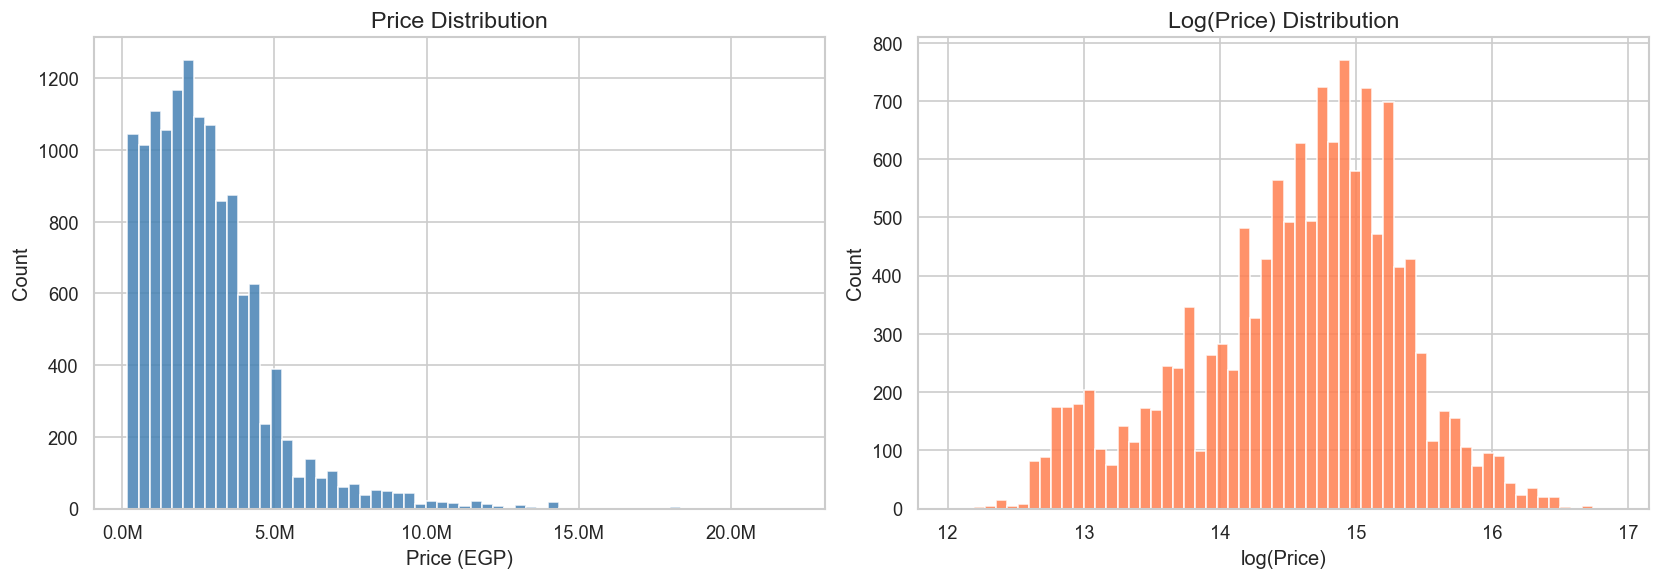

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw price
axes[0].hist(df['Price'], bins=60, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
axes[0].set_title('Price Distribution')
axes[0].set_xlabel('Price (EGP)')
axes[0].set_ylabel('Count')

# Log-scale
log_price = np.log1p(df['Price'])
axes[1].hist(log_price, bins=60, color='coral', edgecolor='white', alpha=0.85)
axes[1].set_title('Log(Price) Distribution')
axes[1].set_xlabel('log(Price)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('price_distribution.png', bbox_inches='tight')
plt.show()

### 2 · Price by Property Type

C:\Users\Hardware\AppData\Local\Temp\ipykernel_10680\1389299751.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='Type_Label', y='Price', order=order,


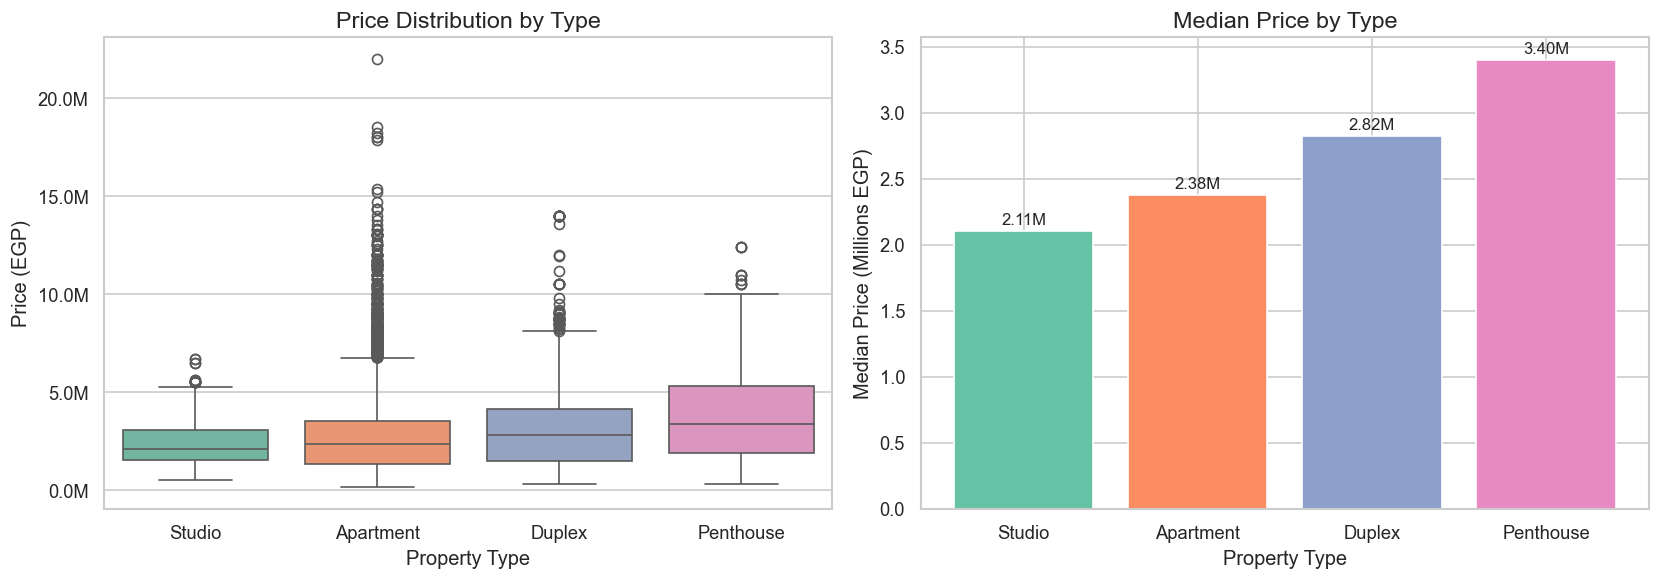

In [32]:
type_map = {0: 'Studio', 1: 'Apartment', 2: 'Duplex', 3: 'Penthouse'}
df_plot = df.copy()
df_plot['Type_Label'] = df_plot['Type'].map(type_map)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot
order = ['Studio', 'Apartment', 'Duplex', 'Penthouse']
sns.boxplot(data=df_plot, x='Type_Label', y='Price', order=order,
            palette='Set2', ax=axes[0])
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
axes[0].set_title('Price Distribution by Type')
axes[0].set_xlabel('Property Type')
axes[0].set_ylabel('Price (EGP)')

# Mean price bar
means = df_plot.groupby('Type_Label')['Price'].median().reindex(order)
axes[1].bar(means.index, means.values / 1e6, color=sns.color_palette('Set2', 4))
axes[1].set_title('Median Price by Type')
axes[1].set_xlabel('Property Type')
axes[1].set_ylabel('Median Price (Millions EGP)')
for i, v in enumerate(means.values):
    axes[1].text(i, v/1e6 + 0.05, f'{v/1e6:.2f}M', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('price_by_type.png', bbox_inches='tight')
plt.show()

### 3 · Area vs Price

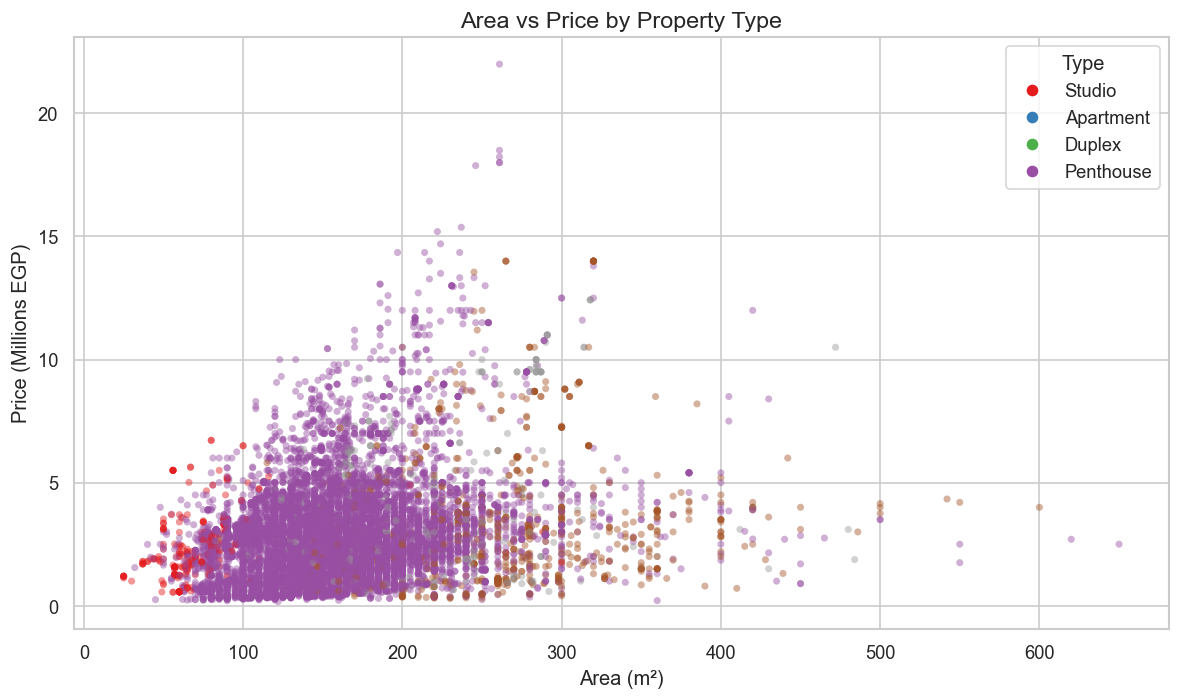

In [33]:
fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(
    df_plot['Area'], df_plot['Price'] / 1e6,
    c=df_plot['Type'], cmap='Set1', alpha=0.45, s=18, linewidths=0
)

# Legend
from matplotlib.lines import Line2D
colors = plt.cm.Set1.colors
legend_els = [Line2D([0],[0], marker='o', color='w', markerfacecolor=colors[i], markersize=8,
                     label=lbl) for i, lbl in enumerate(['Studio','Apartment','Duplex','Penthouse'])]
ax.legend(handles=legend_els, title='Type')

ax.set_xlabel('Area (m²)')
ax.set_ylabel('Price (Millions EGP)')
ax.set_title('Area vs Price by Property Type')
plt.tight_layout()
plt.savefig('area_vs_price.png', bbox_inches='tight')
plt.show()

### 4 · Feature Correlation Heatmap

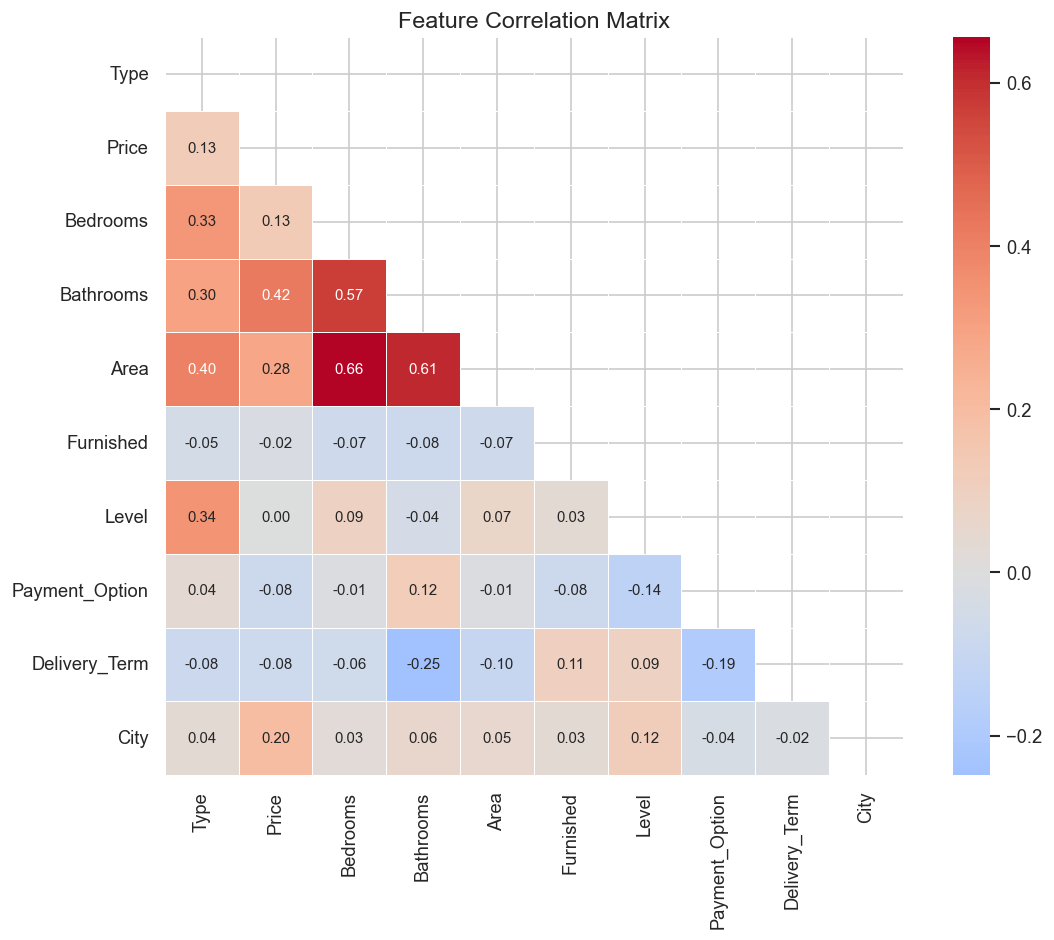

In [34]:
fig, ax = plt.subplots(figsize=(10, 8))
corr = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, ax=ax,
            annot_kws={'size': 9})
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight')
plt.show()

### 5 · Average Price by City

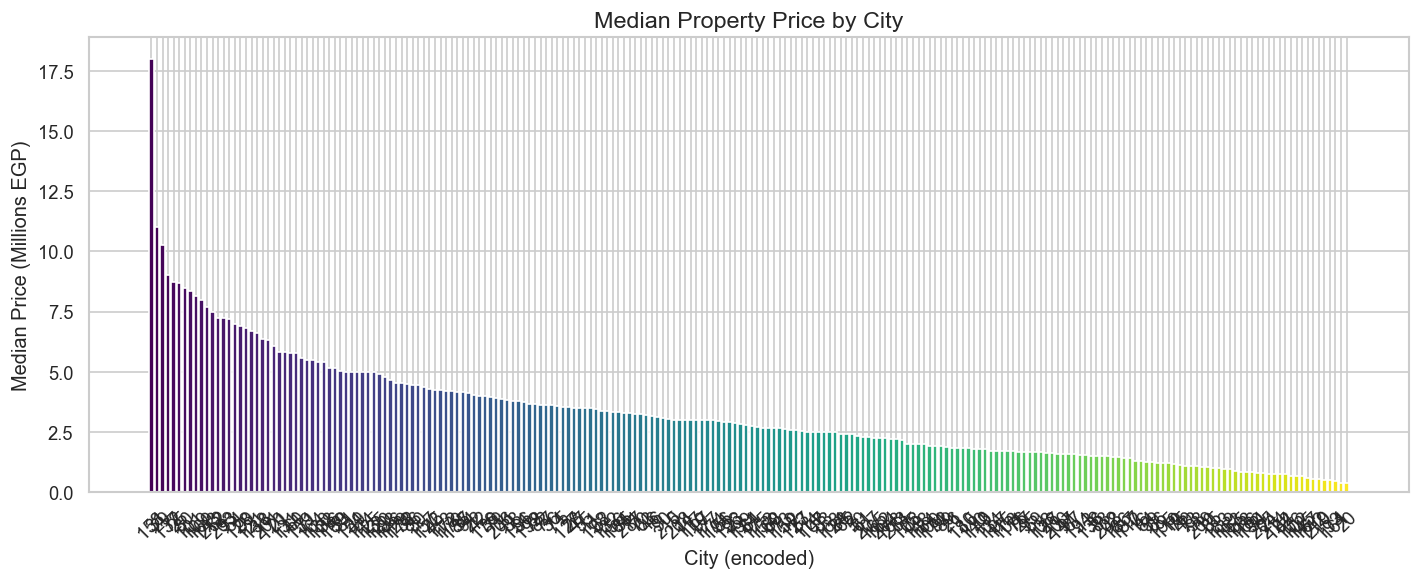

In [35]:
city_price = df.groupby('City')['Price'].median().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(city_price.index.astype(str), city_price.values / 1e6,
              color=sns.color_palette('viridis', len(city_price)))
ax.set_xlabel('City (encoded)')
ax.set_ylabel('Median Price (Millions EGP)')
ax.set_title('Median Property Price by City')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('price_by_city.png', bbox_inches='tight')
plt.show()

### 6 · Bedroom & Bathroom Distribution

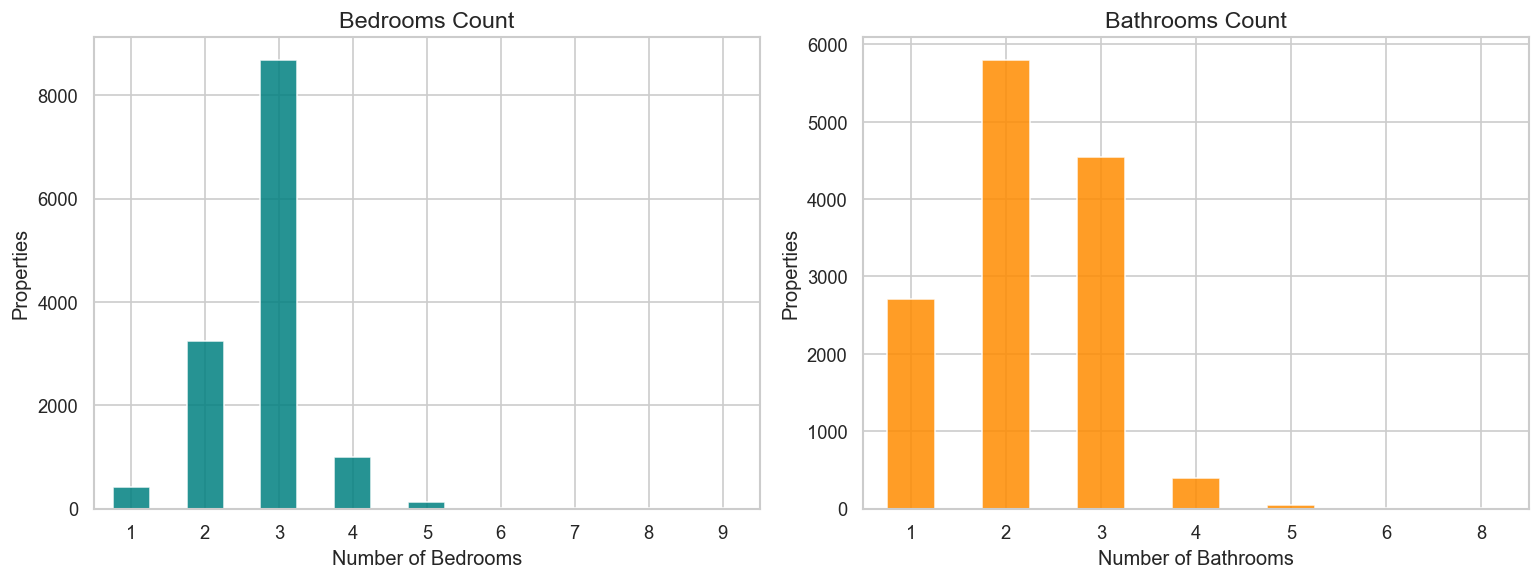

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

df['Bedrooms'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='teal', edgecolor='white', alpha=0.85)
axes[0].set_title('Bedrooms Count')
axes[0].set_xlabel('Number of Bedrooms')
axes[0].set_ylabel('Properties')
axes[0].tick_params(axis='x', rotation=0)

df['Bathrooms'].value_counts().sort_index().plot(
    kind='bar', ax=axes[1], color='darkorange', edgecolor='white', alpha=0.85)
axes[1].set_title('Bathrooms Count')
axes[1].set_xlabel('Number of Bathrooms')
axes[1].set_ylabel('Properties')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('bedrooms_bathrooms.png', bbox_inches='tight')
plt.show()

### 7 · Categorical Features Distribution

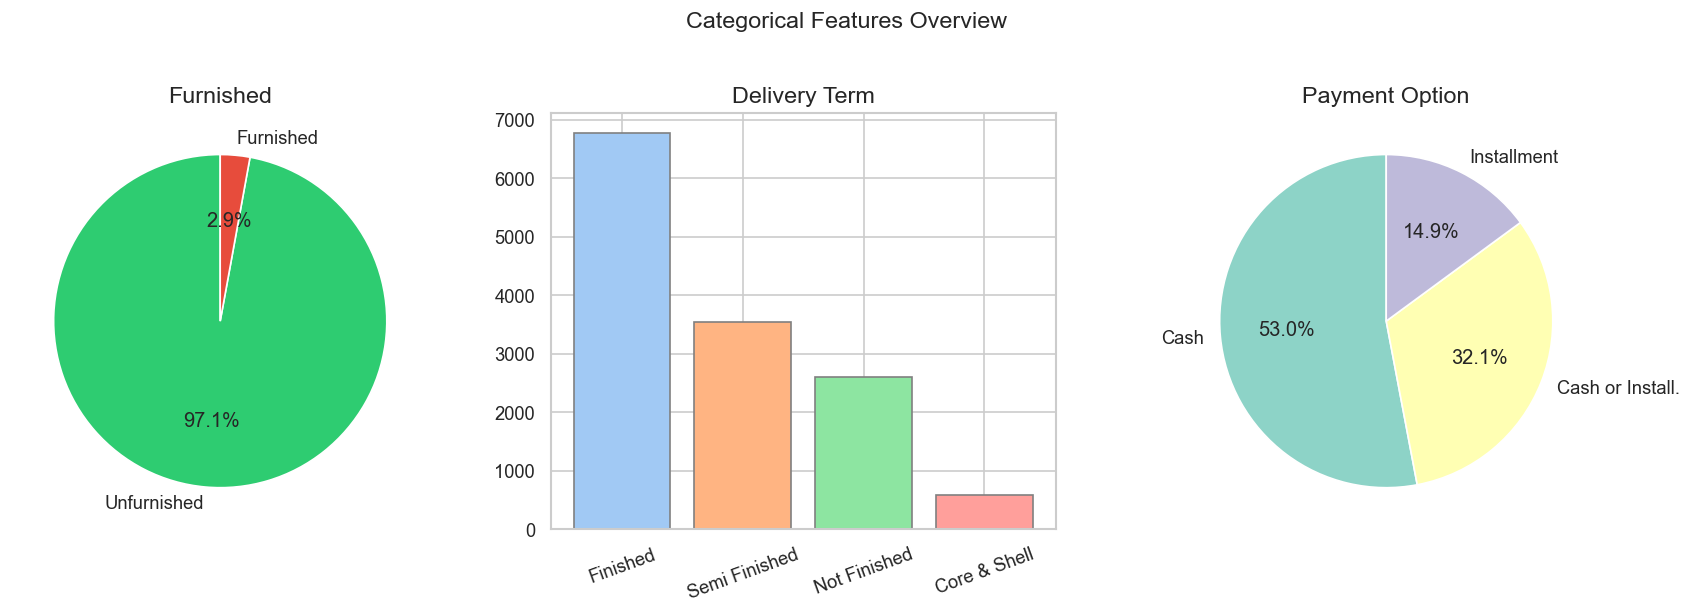

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Furnished
furn_map = {1:'Furnished', 0:'Unfurnished'}
furn_counts = df['Furnished'].map(furn_map).value_counts()
axes[0].pie(furn_counts, labels=furn_counts.index, autopct='%1.1f%%',
            colors=['#2ecc71','#e74c3c'], startangle=90)
axes[0].set_title('Furnished')

# Delivery Term
del_map = {0:'Core & Shell', 1:'Not Finished', 2:'Semi Finished', 3:'Finished'}
del_counts = df['Delivery_Term'].map(del_map).value_counts()
axes[1].bar(del_counts.index, del_counts.values,
            color=sns.color_palette('pastel', len(del_counts)), edgecolor='grey')
axes[1].set_title('Delivery Term')
axes[1].tick_params(axis='x', rotation=20)

# Payment Option
pay_map = {0:'Cash', 1:'Installment', 2:'Cash or Install.'}
pay_counts = df['Payment_Option'].map(pay_map).value_counts()
axes[2].pie(pay_counts, labels=pay_counts.index, autopct='%1.1f%%',
            colors=sns.color_palette('Set3', len(pay_counts)), startangle=90)
axes[2].set_title('Payment Option')

plt.suptitle('Categorical Features Overview', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('categorical_features.png', bbox_inches='tight')
plt.show()

## 🤖 Model Training & Evaluation

In [38]:
xgb.fit(X_train, y_train.values.ravel())
y_pred = xgb.predict(X_test)
performance(xgb, X_train, y_train, y_pred, y_test)

Training Score: 0.9393414258956909
Testing Score: 0.835006058216095
Other Metrics In Testing Data: 
MSE: 678304219136.0
MAE: 535014.0


### 8 · Actual vs Predicted Prices

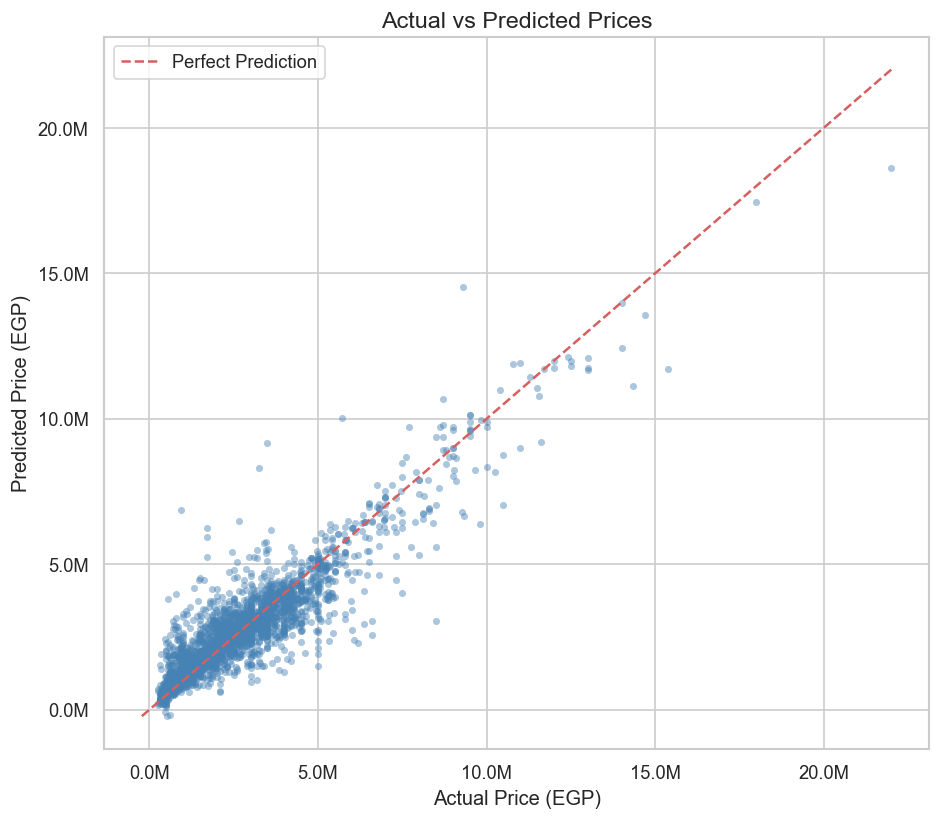

In [39]:
fig, ax = plt.subplots(figsize=(8, 7))

ax.scatter(y_test, y_pred, alpha=0.45, s=18, color='steelblue', linewidths=0)
min_val = min(y_test.values.min(), y_pred.min())
max_val = max(y_test.values.max(), y_pred.max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=1.5, label='Perfect Prediction')
ax.set_xlabel('Actual Price (EGP)')
ax.set_ylabel('Predicted Price (EGP)')
ax.set_title('Actual vs Predicted Prices')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax.legend()
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', bbox_inches='tight')
plt.show()

### 9 · Residuals Analysis

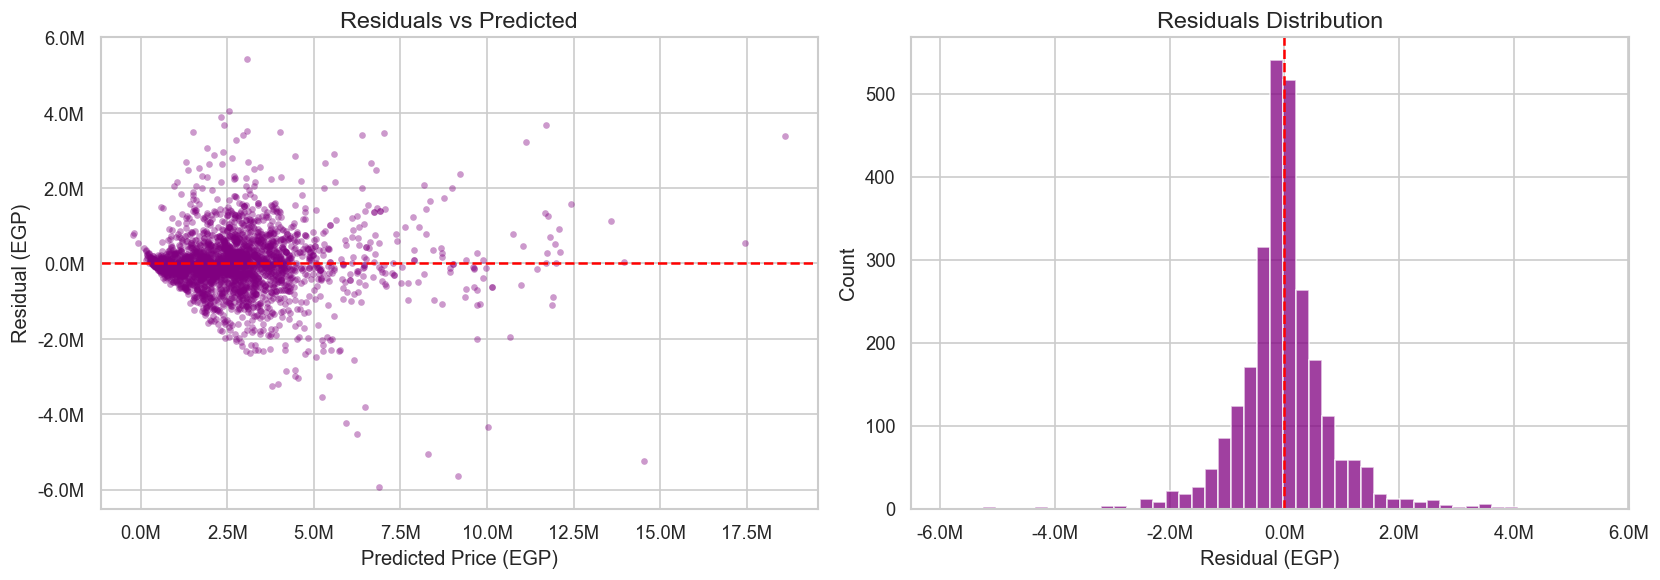

In [40]:
residuals = y_test.values.ravel() - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuals vs Predicted
axes[0].scatter(y_pred, residuals, alpha=0.4, s=16, color='purple', linewidths=0)
axes[0].axhline(0, color='red', lw=1.5, linestyle='--')
axes[0].set_xlabel('Predicted Price (EGP)')
axes[0].set_ylabel('Residual (EGP)')
axes[0].set_title('Residuals vs Predicted')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

# Residuals distribution
axes[1].hist(residuals, bins=50, color='purple', alpha=0.75, edgecolor='white')
axes[1].axvline(0, color='red', lw=1.5, linestyle='--')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
axes[1].set_title('Residuals Distribution')
axes[1].set_xlabel('Residual (EGP)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('residuals.png', bbox_inches='tight')
plt.show()

### 10 · Feature Importance

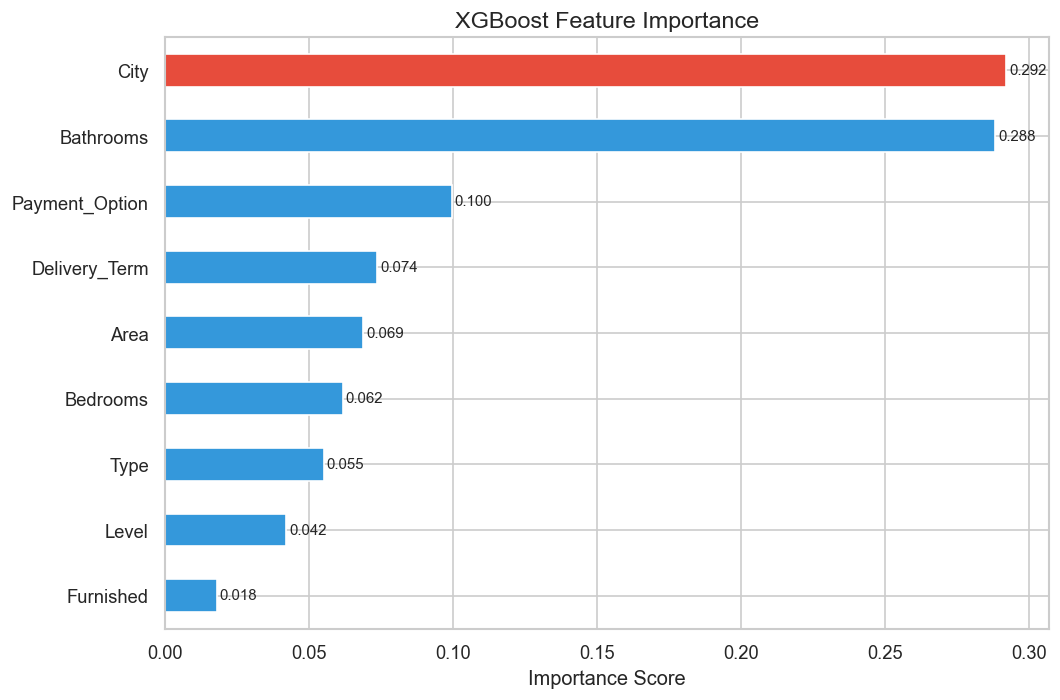

In [41]:
importance = pd.Series(xgb.feature_importances_, index=X.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
colors_imp = ['#e74c3c' if v == importance.max() else '#3498db' for v in importance.values]
importance.plot(kind='barh', ax=ax, color=colors_imp, edgecolor='white')
ax.set_title('XGBoost Feature Importance')
ax.set_xlabel('Importance Score')
for i, v in enumerate(importance.values):
    ax.text(v + 0.001, i, f'{v:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight')
plt.show()

### 11 · Cross-Validation Results

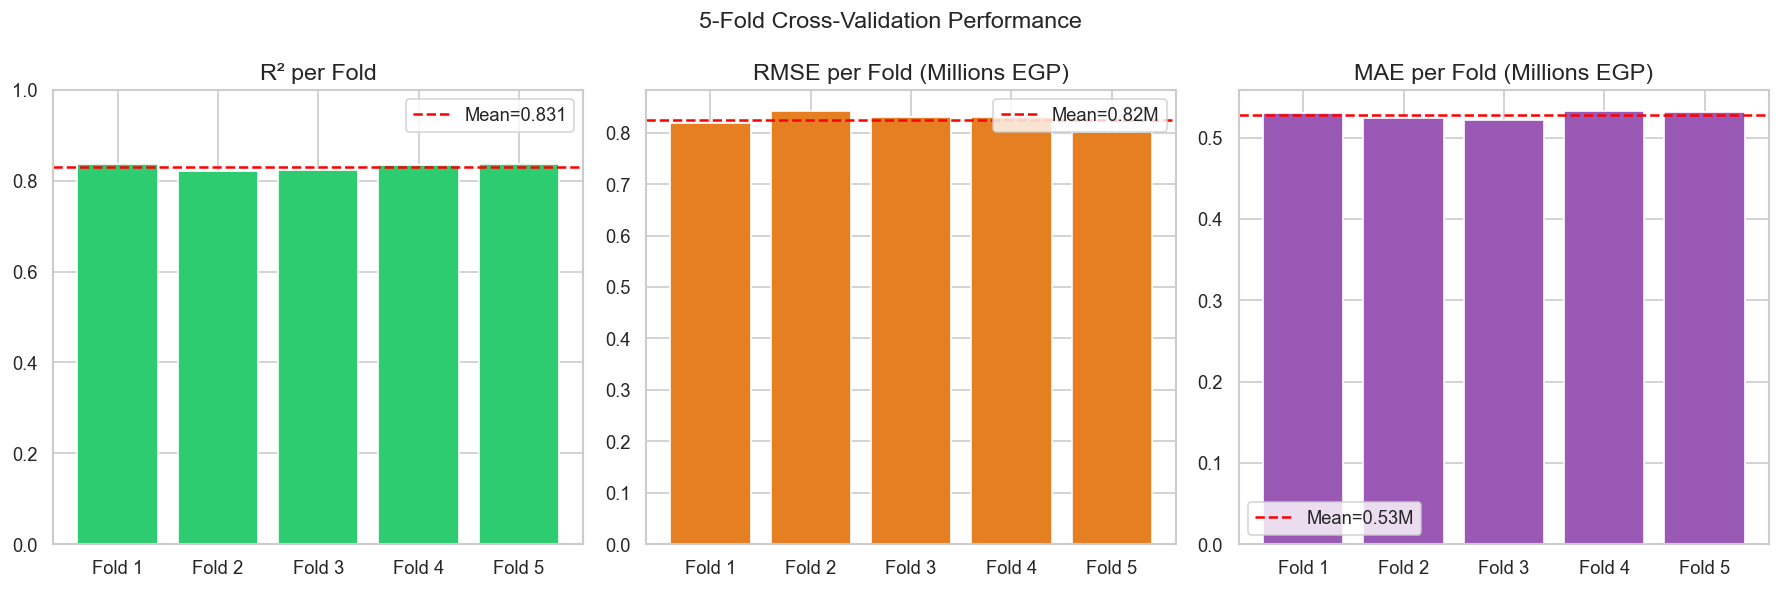

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

folds = [f'Fold {i+1}' for i in range(len(r2_scores))]

# R² per fold
axes[0].bar(folds, r2_scores, color='#2ecc71', edgecolor='white')
axes[0].axhline(r2_scores.mean(), color='red', linestyle='--', lw=1.5, label=f'Mean={r2_scores.mean():.3f}')
axes[0].set_title('R² per Fold')
axes[0].set_ylim(0, 1)
axes[0].legend()

# RMSE per fold
axes[1].bar(folds, rmse_scores / 1e6, color='#e67e22', edgecolor='white')
axes[1].axhline(rmse_scores.mean()/1e6, color='red', linestyle='--', lw=1.5,
                label=f'Mean={rmse_scores.mean()/1e6:.2f}M')
axes[1].set_title('RMSE per Fold (Millions EGP)')
axes[1].legend()

# MAE per fold
axes[2].bar(folds, mae_scores / 1e6, color='#9b59b6', edgecolor='white')
axes[2].axhline(mae_scores.mean()/1e6, color='red', linestyle='--', lw=1.5,
                label=f'Mean={mae_scores.mean()/1e6:.2f}M')
axes[2].set_title('MAE per Fold (Millions EGP)')
axes[2].legend()

plt.suptitle('5-Fold Cross-Validation Performance', fontsize=14)
plt.tight_layout()
plt.savefig('cross_val_results.png', bbox_inches='tight')
plt.show()

### 12 · Price per m² by City

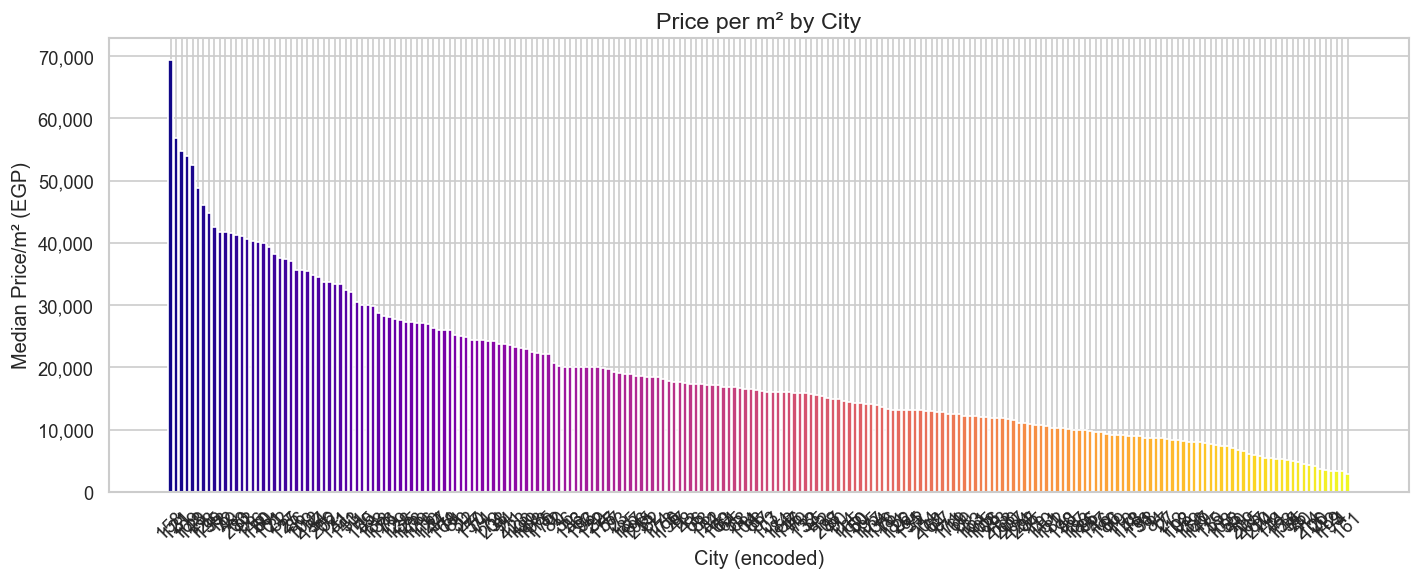

In [43]:
df_plot2 = df.copy()
df_plot2['Price_per_m2'] = df_plot2['Price'] / df_plot2['Area']

city_ppm2 = df_plot2.groupby('City')['Price_per_m2'].median().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(city_ppm2.index.astype(str), city_ppm2.values,
       color=sns.color_palette('plasma', len(city_ppm2)))
ax.set_xlabel('City (encoded)')
ax.set_ylabel('Median Price/m² (EGP)')
ax.set_title('Price per m² by City')
ax.tick_params(axis='x', rotation=45)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.savefig('price_per_m2.png', bbox_inches='tight')
plt.show()

## 🔬 Additional Models Training & Comparison

### Decision Tree

In [44]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=404)
dt.fit(X_train, y_train.values.ravel())
y_pred_dt = dt.predict(X_test)
print('── Decision Tree ──')
performance(dt, X_train, y_train, y_pred_dt, y_test)

── Decision Tree ──
Training Score: 0.9909035725208851
Testing Score: 0.5931532374841462
Other Metrics In Testing Data: 
MSE: 1672581840733.7246
MAE: 688693.451447115


### Random Forest

In [45]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=300, random_state=404, n_jobs=-1)
rf.fit(X_train, y_train.values.ravel())
y_pred_rf = rf.predict(X_test)
print('── Random Forest ──')
performance(rf, X_train, y_train, y_pred_rf, y_test)

── Random Forest ──
Training Score: 0.9624383732743897
Testing Score: 0.7880082034331435
Other Metrics In Testing Data: 
MSE: 871516408609.5569
MAE: 566026.2610831412


### Neural Network (MLP Regressor)

In [46]:
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

nn = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    max_iter=500,
    random_state=404
)
nn.fit(X_train_scaled, y_train.values.ravel())
y_pred_nn = nn.predict(X_test_scaled)
print('── Neural Network (MLP) ──')
performance(nn, X_train_scaled, y_train, y_pred_nn, y_test)

── Neural Network (MLP) ──
Training Score: 0.2912003189654878
Testing Score: 0.29804107509276134
Other Metrics In Testing Data: 
MSE: 2885813183028.744
MAE: 1208448.2793899926


c:\Users\Hardware\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


### 13 · Models Comparison

In [47]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

models_info = [
    ('XGBoost',          y_pred,       xgb,  X_train,        X_test),
    ('Decision Tree',    y_pred_dt,    dt,   X_train,        X_test),
    ('Random Forest',    y_pred_rf,    rf,   X_train,        X_test),
    ('Neural Network',   y_pred_nn,    nn,   X_train_scaled, X_test_scaled),
]

comparison_data = []
for name, preds, model, Xtr, Xte in models_info:
    train_r2  = model.score(Xtr, y_train.values.ravel())
    test_r2   = r2_score(y_test, preds)
    rmse      = np.sqrt(mean_squared_error(y_test, preds))
    mae       = mean_absolute_error(y_test, preds)
    comparison_data.append({'Model': name, 'Train R²': round(train_r2,4),
                            'Test R²': round(test_r2,4),
                            'RMSE (EGP)': f'{rmse:,.0f}',
                            'MAE (EGP)':  f'{mae:,.0f}'})

comparison_df = pd.DataFrame(comparison_data).sort_values('Test R²', ascending=False).reset_index(drop=True)
print(comparison_df.to_string(index=False))

         Model  Train R²  Test R² RMSE (EGP) MAE (EGP)
       XGBoost    0.9393   0.8350    823,592   535,014
 Random Forest    0.9624   0.7880    933,550   566,026
 Decision Tree    0.9909   0.5932  1,293,283   688,693
Neural Network    0.2912   0.2980  1,698,768 1,208,448


### 14 · R² Comparison Chart

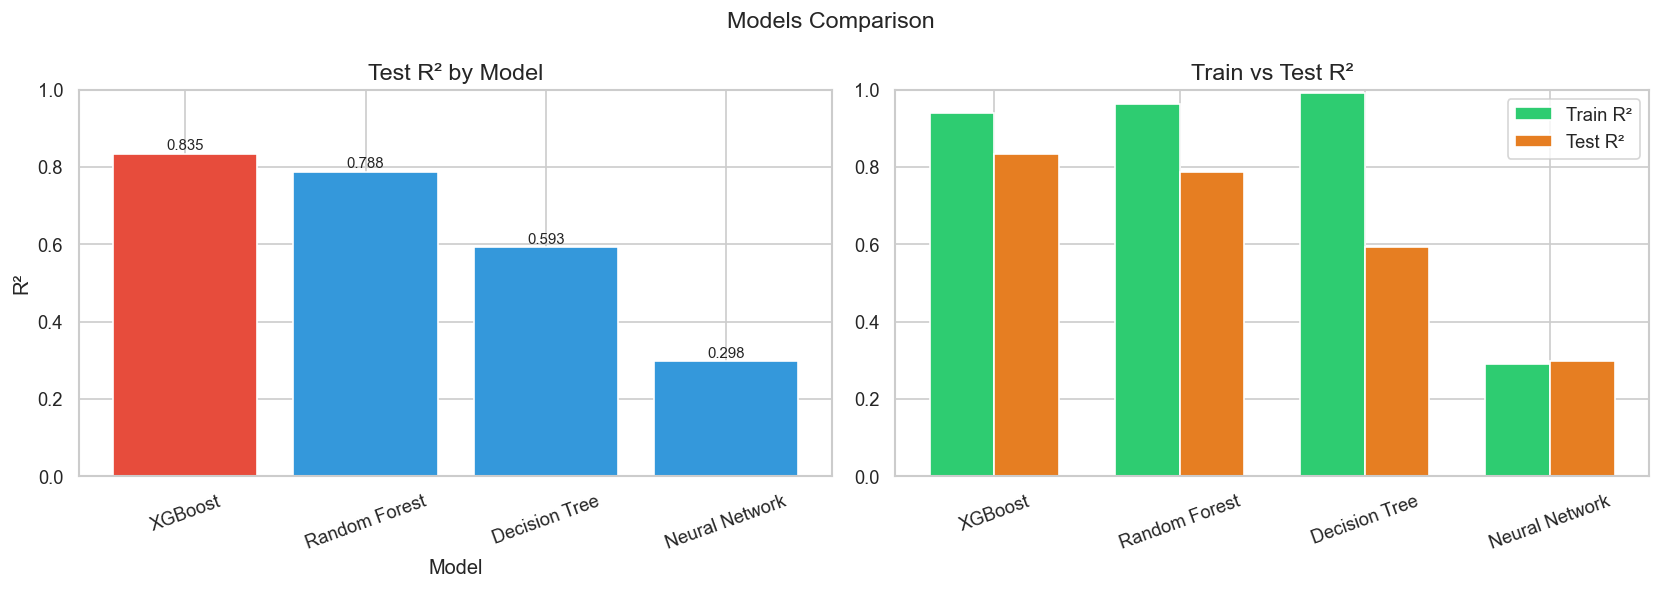

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

model_names  = comparison_df['Model'].tolist()
test_r2_vals = comparison_df['Test R²'].tolist()
train_r2_vals = comparison_df['Train R²'].tolist()

# Test R²
colors_bar = ['#e74c3c' if v == max(test_r2_vals) else '#3498db' for v in test_r2_vals]
axes[0].bar(model_names, test_r2_vals, color=colors_bar, edgecolor='white')
axes[0].set_title('Test R² by Model')
axes[0].set_xlabel('Model')
axes[0].set_ylabel('R²')
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=20)
for i, v in enumerate(test_r2_vals):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)

# Train vs Test R²
x = range(len(model_names))
width = 0.35
axes[1].bar([i - width/2 for i in x], train_r2_vals, width, label='Train R²', color='#2ecc71', edgecolor='white')
axes[1].bar([i + width/2 for i in x], test_r2_vals,  width, label='Test R²',  color='#e67e22', edgecolor='white')
axes[1].set_title('Train vs Test R²')
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(model_names, rotation=20)
axes[1].set_ylim(0, 1)
axes[1].legend()

plt.suptitle('Models Comparison', fontsize=14)
plt.tight_layout()
plt.savefig('models_comparison.png', bbox_inches='tight')
plt.show()

In [49]:
import joblib
import json

# ── 1. Model ──
joblib.dump(xgb, 'model.pkl')

# ── 2. Scaler ──
joblib.dump(scaler, 'scaler.pkl')

# ── 3. Label Encoder (كل الـ encoding maps) ──
label_encoder = {
    "Furnished":      {"Yes": 1, "No": 0},
    "Payment_Option": {"Cash": 0, "Installment": 1, "Cash or Installment": 2},
    "Delivery_Term":  {"Core & Shell": 0, "Not Finished": 1, "Semi Finished": 2, "Finished": 3},
    "Type":           {"Studio": 0, "Apartment": 1, "Duplex": 2, "Penthouse": 3},
    "City":           city_map   
}

with open('label_encoder.json', 'w', encoding='utf-8') as f:
    json.dump(label_encoder, f, ensure_ascii=False, indent=2)

# ── 4. Feature Names ──
feature_names = X.columns.tolist()

with open('feature_names.json', 'w') as f:
    json.dump(feature_names, f, indent=2)

# ── 5. Training Columns ──
training_columns = X.columns.tolist()

with open('training_columns.json', 'w') as f:
    json.dump(training_columns, f, indent=2)

print(" Files saved: model.pkl | scaler.pkl | label_encoder.json | feature_names.json | training_columns.json")

 Files saved: model.pkl | scaler.pkl | label_encoder.json | feature_names.json | training_columns.json
